## TITANIC DATA CLEANING AND VISULAIZATION PROJECT

In [ ]:
## OBJECTIVE
The objective of this project is to clean the Titanic dataset and visualize important patterns.

In [ ]:
## Step 1: LOAD DATASET

In [ ]:
The Titanic dataset is loaded from an online source using Pandas. The first five rows are displayed to understand the struct
ure of the dataset, and the shape is checked to determine the number of rows and columns.

In [1]:
import pandas as pd

url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"

df = pd.read_csv(url)

print(df.head())
print(df.shape)
df.to_csv("Titanic.csv", index=False)

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  
(8

In [ ]:
## Step 2: DATASET INFROMATION 

In [ ]:
The info() function provides details about column names, data types, and missing values present in the dataset.

In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [ ]:
## STEP 3 : CHECKING MISSING VALUES 

In [ ]:
This step is used to identify missing values in the dataset. Missing values can affect analysis and machine learning models, so they must be handled before further processing.

In [3]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [ ]:
## OBSERVATION 

The dataset contains missing values in the following columns:

Age: 177 missing values
Cabin: 687 missing values
Embarked: 2 missing values
The Cabin column has a very large number of missing values, while Age and Embarked have comparatively fewer missing values. These missing values will be handled in the next step.

In [ ]:
## Step 4: HANDLE MISSING VALUES

In [ ]:
The dataset contains missing values in the Age, Cabin, and Embarked columns.

To prepare the dataset for analysis:

Missing Age values are replaced with the median age.
Missing Embarked values are replaced with the most common embarkation port.
The Cabin column is removed because it contains a large number of missing values and provides limited useful information for this analysis.

In [6]:
df["Age"] = df["Age"].fillna(df["Age"].median())

df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

df.drop("Cabin", axis=1, inplace=True)

KeyError: "['Cabin'] not found in axis"

In [ ]:
## OBSERVATION 

The missing values were successfully handled.

Age values were filled using the median.
Embarked values were filled using the mode.
Cabin column was removed from the dataset.
Note: While working on the project, attempting to remove the Cabin column a second time resulted in a KeyError because the column had already been deleted. This confirmed that the column was successfully removed during the first execution.

In [7]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Embarked'],
      dtype='str')

In [ ]:
## Step 5: VERIFY DATA CLEANING

In [ ]:
After handling missing values, the dataset is checked again to ensure that no missing values remain.

In [8]:
df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

In [ ]:
## STEP 6:- IMPORT VISULAIZATION LIBRARIERS 

In [ ]:
Data visualization is an important part of data analysis because it helps identify patterns, trends, and relationships within the dataset.

In this step, Matplotlib and Seaborn libraries are imported to create graphical representations of the Titanic dataset.

In [ ]:
## EXPLANATION 

-> Matplotlib is a Python library used for creating charts and plots.
-> Seaborn is built on top of Matplotlib and provides more attractive and informative statistical visualizations.
-> These libraries will be used to visualize passenger survival, age distribution, and passenger class information.

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
## Step 7: SURVIVAL COUNT VISULAIZATION

In [ ]:
This visualization shows the number of passengers who survived and the number who did not survive the Titanic disaster.

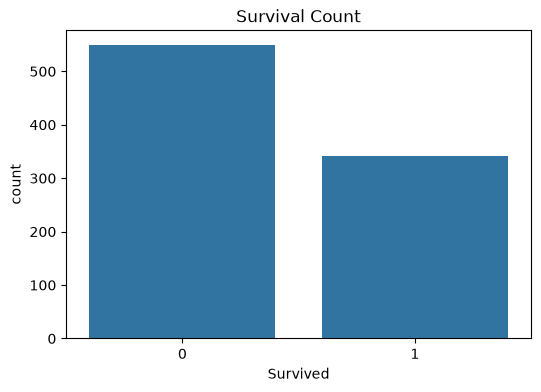

In [14]:
plt.figure(figsize=(6,4))
sns.countplot(x="Survived", data=df)
plt.title("Survival Count")
plt.savefig("survival_count.png")
plt.show()

In [15]:
## OBSERVATION 

The graph shows that the number of passengers who did not survive was greater than the number of passengers who survived.

This indicates that the Titanic disaster resulted in a high casualty rate among passengers.

In [ ]:
## STEP 8: SURVIVAL BY GENDER 

In [ ]:
This visualization compares the survival status of male and female passengers.

The objective is to understand whether gender had an impact on survival during the Titanic disaster.

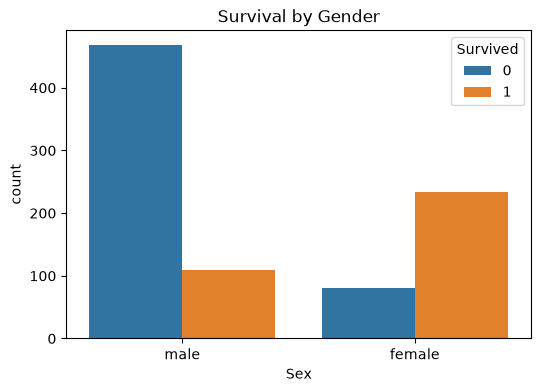

In [16]:
plt.figure(figsize=(6,4))
sns.countplot(x="Sex", hue="Survived", data=df)
plt.title("Survival by Gender")
plt.savefig("survival_by_gender.png")
plt.show()
     


In [ ]:
## OBSERVATION 

-> The graph shows a significant difference in survival rates between male and female passengers.

-> A larger proportion of female passengers survived compared to male passengers. This suggests that gender was an important factor influencing survival during the Titanic disaster.

-> The results support the historical observation that women were given priority during evacuation procedures.

In [ ]:
## STEP 9:-AGE DISTRIUTION ANALYSIS

In [ ]:
This visualization shows the distribution of passenger ages in the Titanic dataset.

The objective is to understand the age composition of passengers and identify the most common age groups aboard the Titanic.

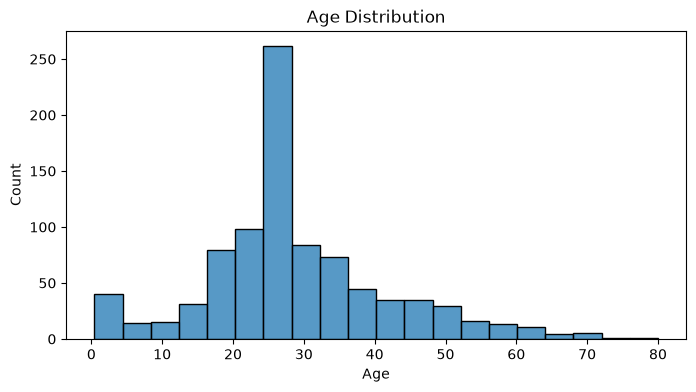

In [17]:
plt.figure(figsize=(8,4))
sns.histplot(df["Age"], bins=20)
plt.title("Age Distribution")
plt.savefig("age_distribution.png")
plt.show()

In [ ]:
## OBSERVATION

-> The age distribution graph shows that most passengers were adults.

-> A large number of passengers were between approximately 20 and 40 years of age. There were fewer passengers in the very young and elderly age groups.

-> The distribution indicates that the Titanic primarily carried adult passengers, with only a small proportion of children and senior citizens.

In [ ]:
## INSIGHT 

Understanding the age distribution is important because age may influence survival patterns. Further analysis can be performed to investigate whether younger or older passengers had different survival rates.

In [ ]:
## STEP 10:- PASSENGER CLASS DISTRIBUTION

In [ ]:
-> This visualization shows the distribution of passengers across different ticket classes.

-> The Titanic dataset categorizes passengers into three classes:

    .First Class (Pclass = 1)
    .Second Class (Pclass = 2)
    .Third Class (Pclass = 3)

-> The objective is to understand how passengers were distributed among these classes.

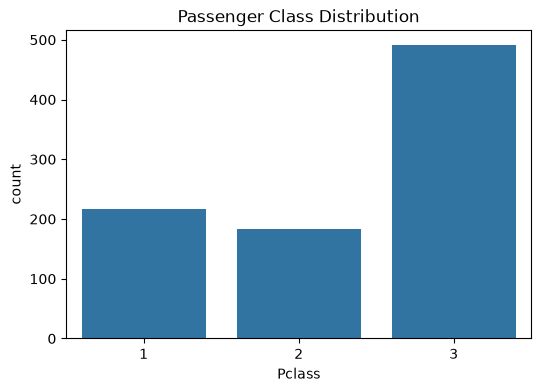

In [18]:
plt.figure(figsize=(6,4))
sns.countplot(x="Pclass", data=df)
plt.title("Passenger Class Distribution")
plt.savefig("passsenger_class_distribution.png")
plt.show()

In [ ]:
## OBSERVATION

-> The graph shows that the majority of passengers traveled in Third Class (Pclass = 3).

-> First Class and Second Class passengers were fewer in number compared to Third Class passengers.

-> This indicates that a large portion of the Titanic's passengers belonged to the lower ticket class category.

In [ ]:
## INSIGHT

-> Passenger class may have influenced survival chances because higher-class passengers generally had better access to facilities and evacuation routes.

-> Further analysis can be conducted to examine the relationship between passenger class and survival rate.

In [ ]:
## CONCULSION

-> In this project, the Titanic dataset was successfully cleaned and analyzed using Python.

In [ ]:
## DATA CLEANING PERFROMED

-> Missing values in the Age column were filled using the median value.
-> Missing values in the Embarked column were filled using the mode value.
-> The Cabin column was removed due to a large number of missing values.

In [ ]:
## KEY FINDINGS

-> More passengers died than survived.
-> Female passengers had a higher survival rate than male passengers.
-> Most passengers were adults between 20 and 40 years of age.
-> The majority of passengers traveled in Third Class.
-> The dataset was successfully cleaned and prepared for further analysis.

In [ ]:
## TOOLS USED 

-> Python
-> Pandas
-> Matplotlib
-> Seaborn
-> Google Colab